# Coursework Set week 4

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Joe Whibley
* Username: jcbwhibley
* Student number: s6411258
* Group (AS1, etc.): AS6

-----

In [ ]:
totalpoints = currentpoints = 0

### Monte Carlo Error Propagation (4 pt) <font color='red'><b>COURSEWORK</b></font>

One of the classical Physic Lab experiment is to use pendulum to calculate the local gravitational acceleration, ``g``, from the measurements of the pendulum length ``L`` and the oscillation period ``T``.

The formula is expressed as follows:

$$ g=\frac{4\pi^2 L}{T^2} $$

You have got a set of measurements of $L=1.00\pm0.01\ \mathrm{(m)}$ and $T=2.01\pm0.02\ \mathrm{(s)}$.

* Like in Physics Lab, use Tyler expansion described above to propagate the error. Write your derivation in Markdown.

* Calculate the error of the derived ``g``.

* Apply Monte Carlo error propagation to estimate the value and uncertainty of ``g``.

* Make appropriate comments.

* Compare the two results.

In [6]:
import numpy as np
import scipy
import math

L = 1
T=2.01
erL=0.01
erT=0.02

cst = 4*math.pi**2    #constant value


parder_L = (cst)/(T**2)
parder_T = (cst*(-2)*L)/(T**3)       #defining the partial derivatives

erg = abs((parder_L*erL)**2+(parder_T*erT)**2)**(0.5)       #using taylor expansion to derive error for g

g = (cst*L)/T**2        #deriving value of g straight from equation
print(f"the derived taylor expansion value of g is: {g} +- {erg:2f}")


#calculate a different value for error? compare and make comment

Ldist = np.random.normal(L,erL,100000)            #make normal distribution for values of L and T
Tdist = np.random.normal(T, erT, 100000)

gdist = (cst*Ldist)/Tdist**2       #put the distributions into the function

mu = np.mean(gdist)              #finding values of g and its error using monte carlo method
stn = np.std(gdist)

print(f"the monte carlo value of g is: {mu} +- {stn}$")


the derived taylor expansion value of g is: 9.77164367326488 +- 0.217631
the monte carlo value of g is: 9.77469383267331 +- 0.21791362632625194$


$$ g=\frac{4\pi^2 L}{T^2} $$

$$\sigma g = \frac{\partial g}{\partial L} \Delta L + \frac{\partial g}{\partial T} \Delta T $$

$$\frac{\partial g}{\partial L} = \frac{4 \pi^2}{L^2}$$

$$\frac{\partial g}{\partial T} = \frac{(-2) 4 \pi^2 L}{T^3}$$


$$\sigma g = \sqrt{(\frac{4 \pi^2}{L^2} \Delta L)^2 + (\frac{(-2) 4 \pi^2 L}{T^3} \Delta T)^2}$$

$$ g = 9.8 \pm 0.2\,\,\, (m/s^2)$$

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Complex roots of a quadratic equation (4 pt) <font color='red'><b>COURSEWORK</b></font>
  
Use the information in the notebook about complex numbers to write a program that can calculate the (complex) roots of a quadratic equation with the quadratic formula:

$$ y=ax^2+bx+c $$

The requirement of this program is as follows:

* User can supply constants ``a``, ``b`` and ``c`` with Python function `input()`.
* The program can deal with complex roots.
* Your program must print the equation with its constants and its roots.
* The solutions must be inserted to the original equation to prove that $f(x)=0$.

**Answer**:

In [43]:
import math
from IPython.display import display, Math


display(Math(rf"y=ax^2+bx+c"))
print()
a = float(input("input a:"))   #input floats
b = float(input("input b:"))
c = float(input("input c:"))

det = (b**2)-4*a*c   #define determinant
x=[]



if det > 0:        #if there are 2 solutions, find both using determinant
    sol_1 = (-b + math.sqrt(det))/(2*a)
    sol_2 = (-b - math.sqrt(det))/(2*a)
    
    print (f"the solutions are x={sol_1} and x={sol_2}")
    x.append(sol_1)
    x.append(sol_2)
    
elif det == 0:                #if there is 1 solution (det=0) find the solution
    sol_3 = (-b)/(2*a)

    print(f"the one solution is x={sol_3}")
    x.append(sol_3)
    
else:               #imaginary solutions
    absol = abs(det)      #making it so you can take roots of the determinant
    root = math.sqrt(absol)
    sol_4 = (-b+1j*(root))/(2*a)             #imaginary application of the quadratic formula
    sol_5 = (-b+1j*(root))/(2*a) 
    
    print(f"the imaginary solutions are x=({sol_4:2f}) and x=({sol_5:2f})") 
    x.append(sol_4)
    x.append(sol_5)


for i in x:
    if a*i**2 + b*i + c == 0:
        display(Math(rf"0={a}*({i})^2+{b}*({i})+{c}"))
    else:
        print(f"you have broken math, the quadratic formula is false")




<IPython.core.display.Math object>

input a: 1
input b: 5
input c: 6


the solutions are x=-2.0 and x=-3.0


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Area under a Gaussian (6 pt) <font color='red'><b>COURSEWORK</b></font>

A one dimensional Gaussian function is given by:

$$f(x) = A\ e^{\frac{-{(x-x_0)}^2}{2 \sigma^2}} + z_0$$

$A$ is the amplitude, $x_0$ is the position of the peak, $\sigma$ is the width of the peak
and $z_0$ is the offset in $y$.  

This function can be written in Python as follows:

```python
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
```

1. Set in the calling environment:
```python
    A = 1.0
    x0 = 0.0
    sig = 2.0
    z0 = 0.0
```
2. Plot this function between -10 and 10 with 200 samples.
3. Use function `scipy.integrate.quad()` to find the area between ``x=0`` and ``x=2.5``.
4. Use function `matplotlib.pyplot.fill_between()` to mark that area in your plot.
5. Calculate the area between $-\infty$ and $\infty$ ($\approx 5.01$).
6. Given is the integral for the total area under the curve:

    $$\int _{-\infty }^{\infty }Ae^{-(x-x_0)^{2}/(2\sigma^{2})}\,\mathrm{d}x=A \sigma \cdot {\sqrt {2\pi }}$$

   Calculate this area for the values of the parameters given above and prove with ``quad()`` that the two are the same.

7. Make the last part an executable script, called ``gaussarea``. The user can enter values for ``A``, ``x0``, ``sig`` and ``z0`` and the integration limits. The programme then calculates the area under the curve between the integration limits using function ``quad()``. The programme must includes a plot of the curve, the integration area, and the value of that area in a legend.
8. Insert the generated plot in a separate markdown cell below your code cell, and upload your script to GitHub. Provide your GitHub website link in the notebook too for TA to check. 
   
**Answers**:   

the integral of the gaussian distribution from 0 to 2.5 is: 1.9769788548675902
the scipy value of the integral from negative to positive infinty is: 5.013256549262001
the formulaeic value for the integral is: 5.0132565492620005


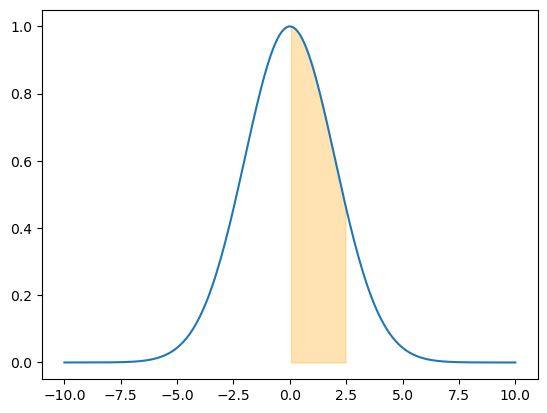

In [23]:
import numpy as np
import math
import scipy
import matplotlib.pyplot as plt

#1 set calling environment 
A = 1.0
x0 = 0.0
sig = 2.0
z0 = 0.0

#defining the gauss function with multiple variable inputs
def gauss(x, A, x0, sigma, z0):
    return (A*np.exp(-(x-x0)**2/(2*sigma**2)))+z0

#3
#defining the gauss function with pretset basics
def gausss(x):
    return((A*np.exp(-(x-x0)**2/(2*sig**2)))+z0)

integral = scipy.integrate.quad(gausss, 0, 2.5)                      #integrating from 0 to 2.5
print(f"the integral of the gaussian distribution from 0 to 2.5 is: {integral[0]}")



#plotting the gaussian dist
x = np.linspace(-10,10,200)
y= gausss(x)
plt.plot(x,y)

#fill between
mask = (x>=0) & (x<=2.5)
plt.fill_between(x[mask], y[mask], color='orange', alpha=0.3)


#scipy integration
sci_integ = scipy.integrate.quad(gausss, -np.inf, np.inf)
print(f"the scipy value of the integral from negative to positive infinity is: {sci_integ[0]}")

#given value of integral
given_integ = A*sig*math.sqrt(2*math.pi)
print(f"the formulaeic value for the integral is: {given_integ}")
print("the scipy quad integral and the formulaeic integral gives the same value")



input amplitude A: 1
input position of peak x0: 9
input width of curve sigma: 0.5
input the offset in the y axis z0: 0
input lower limit of integration a: 5
input upper limit of integration b: 8


the area under the curve with your bounds (a&b) is: 0.02851306199644523


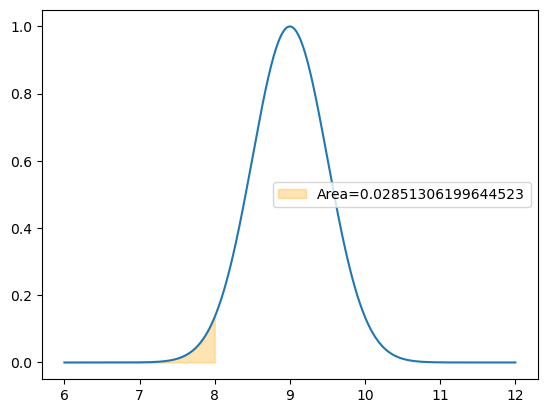

In [50]:
#gaussarea
#7 make is user input based
import numpy as np
import math
import scipy


A = float(input("input amplitude A:"))
x0 = float(input("input position of peak x0:"))
sig = float(input("input width of curve sigma:"))
z0 = float(input("input the offset in the y axis z0:"))

a = float(input("input lower limit of integration a:"))
b = float(input("input upper limit of integration b:"))

def gausss(x):
    return((A*np.exp(-(x-x0)**2/(2*sig**2)))+z0)

integral = scipy.integrate.quad(gausss, a, b)
print(f"the area under the curve with your bounds (a&b) is: {integral[0]}")


x = np.linspace((x0-6*sig), (x0+6*sig), 100000)
y = gausss(x)

plt.plot(x, y)


mask = (x>=a) & (x<=b)
plt.fill_between(x[mask], y[mask], color='orange', alpha=0.3, label=f"Area={integral[0]}")
plt.legend()

Github link:
https://github.com/Whibletm/PROGNUM-repo/tree/main/Task4

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Calculate integral of a user supplied function (6 pt) <font color='red'><b>COURSEWORK</b></font>

Write a programme that calculates the integral of any function from the user input using ``eval()``, which is a string representing a function and a variable (floating number) for which the function will be evaluated.

* Call from ``numpy import sin, cos, exp, pi`` to apply these functions and constants in your code.
* Use ``scipy.integrate.quad()`` to calculate the integral of the formula below between $x=0$ and $x=\pi$
* Use Monte Carlo Integration to calculate the integral of the formula below for $x=0$ and $x=\pi$

$$ f(x)=x^4+e^{\sin{x}+\cos{x}} $$

Make the function robust with try/except clauses. Demonstrate exceptions for wrong expressions and unknown functions in an expression (NameError) etc. Print messages that tell a user what they have done wrong!

Make the above code an executable script called ``interate_user_function``, and upload to GitHub.

* Create a separate cell, and use SymPy expression to calculate the integral of the formula below for $x=0$ and $x=\pi$.

In [13]:
#1
import numpy as np
import math
import scipy


func = lambda x: (x**4 + math.e**(math.sin(x) + math.cos(x)))   #fct for scipy
funct = lambda x: (x**4 + np.e**(np.sin(x) + np.cos(x)))  #fct for monte carlo (needs arrays)
a = 0            #lower bound
b = math.pi      #upper bound
N = 100000       #precision number for montecarlo
x = np.random.uniform(a,b, N)       #range of x

integral_s = scipy.integrate.quad(func, a, b)       #integral w scipy
print(f"the scipy derived integral is: {integral_s[0]}")


integral_m = ((b-a)/N)*sum(funct(x))         #integral w monte carlo
print(f"the monte carlo integral is: {integral_m}")




the scipy derived integral is: 68.72932272689113
the monte carlo integral is: 68.69376826246292


In [15]:
#2 user input
import numpy as np
from numpy import sin, cos, exp, pi
import math
import scipy


try:
    a = eval(input("input lower bound:"))
    b = eval(input("input upper bound:"))
except Exception:
    print("you inputted something wrong, try again!")

N=100000

x = np.random.uniform(a,b, N)


try:
    func = input("input function in python (in terms of x):")
    function = lambda x: eval(func)  
    integral_s = scipy.integrate.quad(function, a, b)
    print(f"the scipy derived integral to your function is: {integral_s[0]}")
    integral_m = ((b-a)/N)*sum(function(x))         #integral w monte carlo
    print(f"the monte carlo integral is: {integral_m}")

except Exception:
    print("you inputted something wrong, try again!")
    

input lower bound: y


you inputted something wrong, try again!


input function in python (in terms of x): x


the scipy derived integral to your function is: 4.934802200544679
the monte carlo integral is: 4.942955848995311


In [10]:
#3  sympy integral 
import sympy
from sympy.abc import x

func = "x**4 + exp(sin(x) + cos(x))"
funct = sympy.sympify(func)

integral = sympy.N(sympy.integrate(funct, (x, 0, sympy.pi)))
print("the sympy calculated integral is:", integral)

the sympy calculated integral is: 68.7293227268911


Github link: https://github.com/Whibletm/PROGNUM-repo/tree/main/Task4

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Hertzsprung–Russell (HR) diagram (6 pt) <font color='red'><b>COURSEWORK</b></font>

``Hertzsprung-Russell (HR) diagram``, which indicates the stellar evolution, is an important astrophysical plot graphing stellar luminosity (brightness, absolute magnitude) against surface temperature (or colour). This diagram clearly states the evolutionary pathways of stars and where they are in their lifetime. With this, we classify several important stages of a star's life -- main sequence stars, giants, or white dwarfs. 

In this exercise, a combined APOGEE/Gaia star catalog has been prepared for you to create an HR diagram -- download the catalogue from the BrightSpace: ``APOGEE+Gaia_stars.fits``

* To read FITS file, you need AstroPy, which is a library that is widely used in Astronomy.

```python
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
```

* "data" is a AstroPy data class, but it can be used like a ndarray as follows.

```python
print(data[0]) # The first row of the catalogue
print(data['STARFLAG']) # List all rows in the column of "STARFLAG"
print(data['STARFLAG'][:10]) # Print the first 10 elements in the column of "STARFLAG"
print(data['STARFLAG'][-10:]) # Print the last 10 elements in the column of "STARFLAG"
```

* Firstly, let's select data with good quality and robust measurements using the following criteria:
    * STARFLAG == 0
    * ASPCAPFLAG == 0
    * SNR > 10
    * GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
    * GAIAEDR3_PHOT_G_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_BP_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_RP_MEAN_MAG is not NaN value

* From the selected data, let's randomly choose about **80% of the data** for plotting the HR diagram. 

* The HR diagram contains
    * $x$-axis: colour -- BP-RP
    * $y$-axis: absolute magnitude -- $M_G$


**<span style="color:red">Warning</span>**: note that from observation, we only have apparent magnitude (i.e. observed magnitude). To convert into absolute magnitude requires **Distance Modulus**: 

$$ M_G = m_G + 5\log10{(\mathrm{parallax}/1000)} + 5 $$

* Apply a rough binary classification scheme to separate giant branch and main sequence (MS) stars.
    * Giant branch: $ M_G<3.5 $ and $(BP-RP)>0.8$
    * MS: assume the rest of the data is MS

* It seems that we do not have sufficient samples in the White Dwarf (WD) region. Use the following criteria to draw vertical and horizontal lines, as well as define a box indicating the location of WD on the HR diagram.
    * $(BP-RP)\leq0.8$ and $ M_G>10 $ (very faint)
 
* Make a scatter plot and customise it to be look like the plot shown here.

<img src="attachment:14037eb3-1593-4349-8d4a-ae0bd96b6e97.png" alt="HR Diagram" width="600">

Text(0, 0.5, 'Mg')

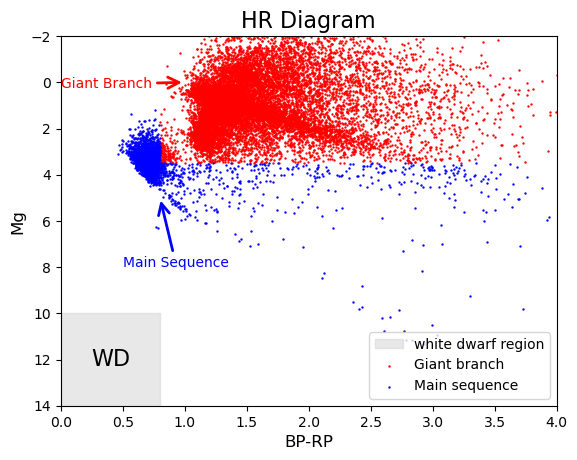

In [1]:
from astropy.io import fits
import numpy as np
import math
import matplotlib.pyplot as plt


# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

mask = (
    (data['STARFLAG'] == 0) &            #creates mask to filter the data with conditions
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)

data_clean = data[mask]    #applying the mask

n=len(data_clean)
indices = np.random.choice(n, int(0.1*n), replace=False)      #makes indice list, (length of list, size of sample, replace=False doesnt replace data points once they have been picked)
data_80 = data_clean[indices]  #cleaned data              #COMMENT: 80% made it unseeable so i used 10% instead


parrallax = data_80['GAIAEDR3_PARALLAX']       #defining parrallax and mg
mg=data_80['GAIAEDR3_PHOT_G_MEAN_MAG']


Mg=mg+(5*np.log10(parrallax/1000))+5        #finding absolute magnitude

x_axis = data_80['GAIAEDR3_PHOT_BP_MEAN_MAG'] - data_80['GAIAEDR3_PHOT_RP_MEAN_MAG']         #defining BP-RP


giant_mask = (Mg<3.5)&(x_axis>0.8)


plt.annotate(                                #.annotate( 'string', color, fontsize, xy(head coords), xytext(put text/start))
    'Main Sequence',  
    color='b',
    fontsize=10,
    xy=(0.8, 5),      # arrow head position
    xytext=(0.5, 8),   # arrow start position +text position
    arrowprops=dict(arrowstyle='->', color='b', mutation_scale=20, lw=2))  #mutation scale makes bigger


plt.annotate(                                #.annotate( 'string', color, fontsize, xy(head coords), xytext(put text/start))
    'Giant Branch',  
    color='r',
    fontsize=10,
    xy=(1, 0),      # arrow head position
    xytext=(0, 0.25),   # arrow start position +text position
    arrowprops=dict(arrowstyle='->', color='r', mutation_scale=20, lw=2))  #mutation scale makes bigger


xwd=np.linspace(0,0.8,10)
plt.fill_between(xwd, 10,16,
                 color='lightgrey',
                 alpha=0.5,
                 label='white dwarf region')
plt.text(0.4,12,'WD',fontsize=16, ha='center', va='center')


plt.scatter(x_axis[giant_mask], Mg[giant_mask], color='r', label="Giant branch", s=0.5)          #giant branch
plt.scatter(x_axis[~giant_mask], Mg[~giant_mask], color='b', label='Main sequence', s=0.5) #making scatter plot
plt.legend(loc='lower right')
plt.xlim(0,4)
plt.ylim(14,-2)
plt.title('HR Diagram', size=16)
plt.xlabel('BP-RP', size=12)
plt.ylabel('Mg', size=12)

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")